Estimators: 10, Accuracy: 0.8209642747466476
Estimators: 50, Accuracy: 0.8270037874910431
Estimators: 100, Accuracy: 0.8352953219367386
Estimators: 150, Accuracy: 0.8364213327873887
Estimators: 200, Accuracy: 0.8366260620329614

Best Accuracy: 0.8366260620329614
Best n_estimators: 200
Confusion Matrix:
 [[7186  286]
 [1310  987]]


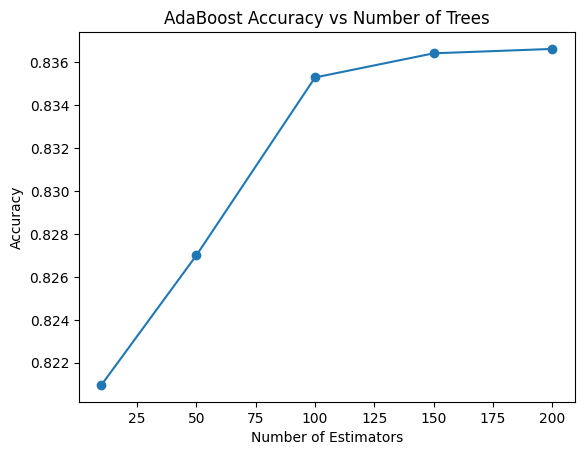

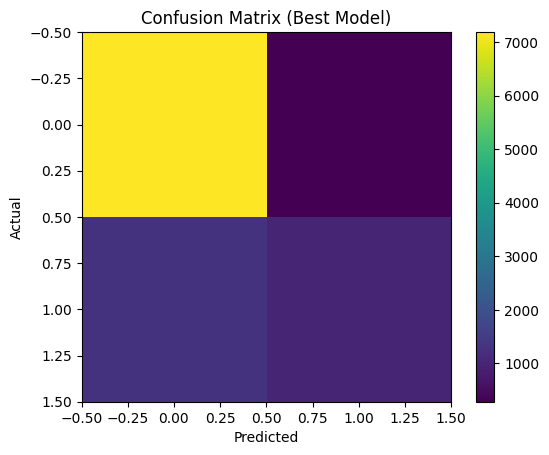

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("income.csv")

# Handle categorical data
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Split features & target (assume last column is target)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# =========================
# ✅ Try different estimators
# =========================
estimators = [10, 50, 100, 150, 200]
accuracies = []

best_acc = 0
best_n = 0

for n in estimators:
    model = AdaBoostClassifier(n_estimators=n, random_state=0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    print(f"Estimators: {n}, Accuracy: {acc}")

    if acc > best_acc:
        best_acc = acc
        best_n = n
        best_cm = confusion_matrix(y_test, y_pred)

# =========================
# ✅ Best Result
# =========================
print("\nBest Accuracy:", best_acc)
print("Best n_estimators:", best_n)
print("Confusion Matrix:\n", best_cm)

# =========================
# ✅ Accuracy Graph
# =========================
plt.figure()
plt.plot(estimators, accuracies, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Accuracy vs Number of Trees")
plt.show()

# =========================
# ✅ Confusion Matrix Visualization
# =========================
plt.figure()
plt.imshow(best_cm)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()